In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('https://raw.githubusercontent.com/sadeembader/Mining_project/refs/heads/main/Dataset/Raw_dataset.csv')

In [3]:
Preprocessed_dataset = df.copy()

# 1-Data Analysis

**Five number summary**

In [ ]:
df.describe().loc[['min','25%','50%','75%','max']]

,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Driver_Age,Driver_Experience,Accident
min,0.0,30.0,1.0,0.0,18.0,9.00,0.0
25%,0.0,50.0,2.0,0.0,30.0,26.00,0.0
50%,1.0,60.0,3.0,0.0,43.0,39.00,0.0
75%,2.0,80.0,4.0,0.0,56.0,52.75,1.0
max,2.0,213.0,14.0,1.0,69.0,69.00,1.0


**Boxplots**

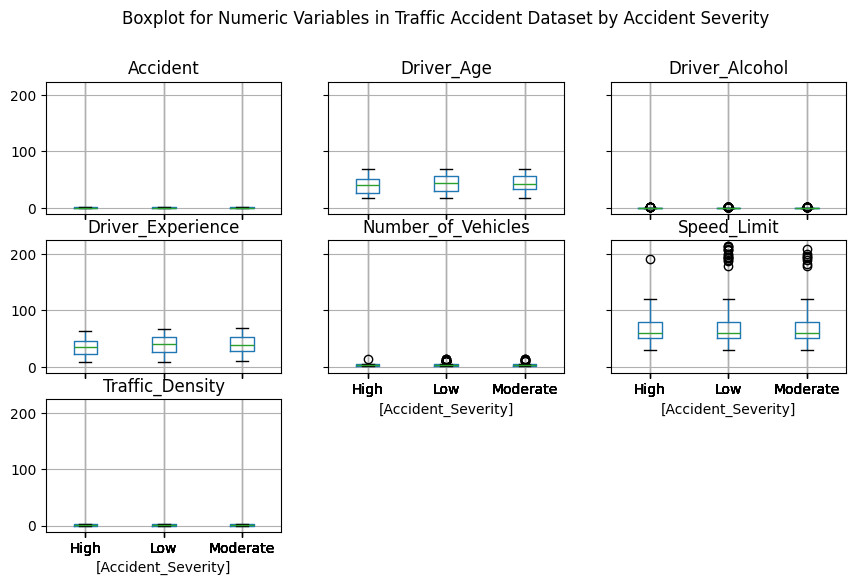

In [ ]:
df.boxplot(by='Accident_Severity', figsize=(10,6))
plt.suptitle('Boxplot for Numeric Variables in Traffic Accident Dataset by Accident Severity', y=1.02)
plt.show()

**Outliers**

In [ ]:
numeric_df = df.select_dtypes(include='number')

threshold = 3

for column in numeric_df.columns:
    data = numeric_df[column].dropna()

    mean = np.mean(data)
    std_dev = np.std(data)

    outliers = [value for value in data if abs(value - mean) > threshold * std_dev]

    print(column, "Outliers:", outliers)

Traffic_Density Outliers: []
Speed_Limit Outliers: [195.0, 200.0, 206.0, 178.0, 208.0, 213.0, 190.0, 196.0, 188.0, 195.0, 194.0, 189.0, 193.0, 189.0, 185.0, 199.0, 192.0, 213.0, 198.0, 192.0, 206.0, 212.0, 181.0, 208.0, 178.0]
Number_of_Vehicles Outliers: [11.0, 12.0, 13.0, 12.0, 11.0, 11.0, 14.0, 11.0, 10.0, 14.0, 13.0, 11.0, 14.0, 13.0, 11.0, 10.0, 14.0, 11.0, 10.0, 11.0, 10.0, 10.0, 13.0]
Driver_Alcohol Outliers: []
Driver_Age Outliers: []
Driver_Experience Outliers: []
Accident Outliers: []


We used the Standard Deviation Method by calculated the difference by subtracting the mean from each value, then compared the result with the standard deviation threshold to detect outliers.

**Bar plots**

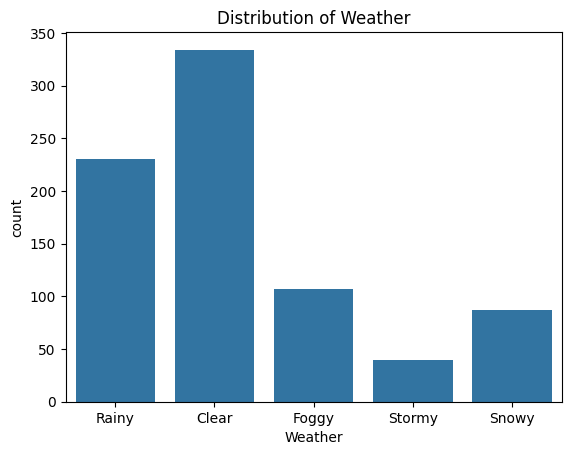

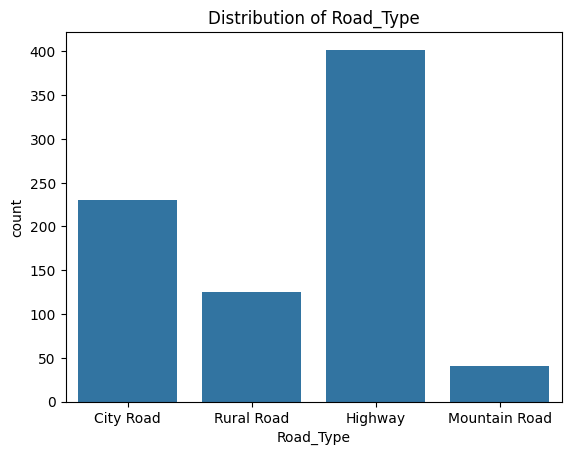

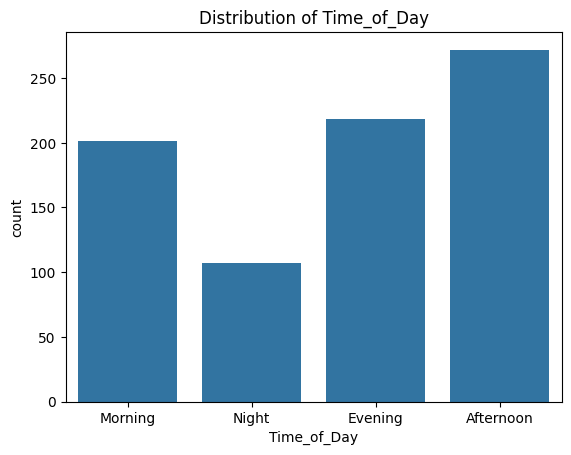

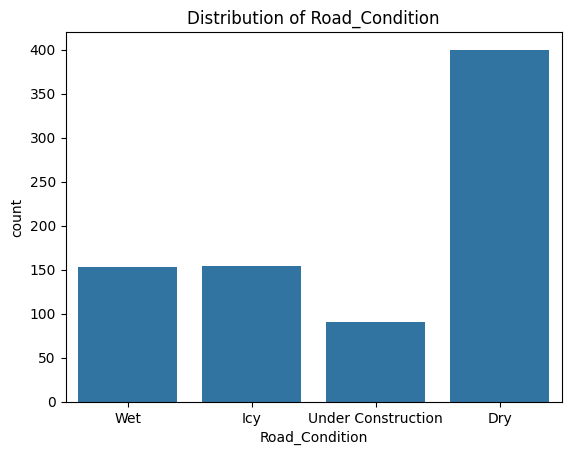

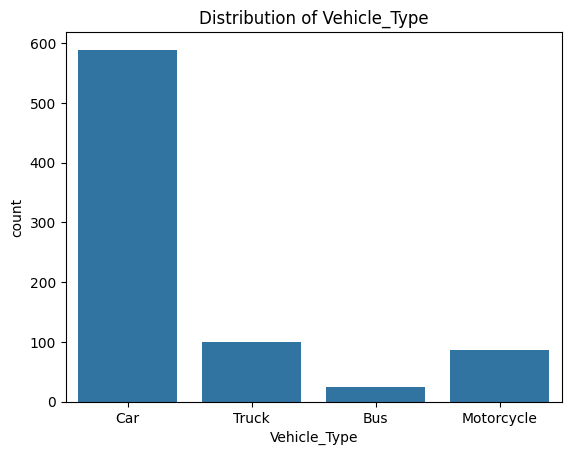

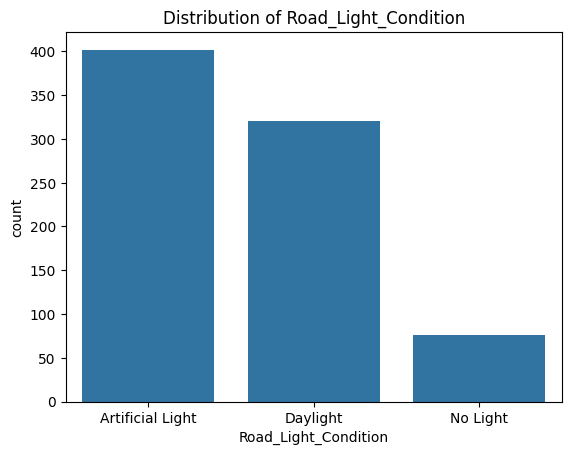

In [ ]:
cat_cols = ['Weather', 'Road_Type', 'Time_of_Day', 'Road_Condition', 'Vehicle_Type', 'Road_Light_Condition']
for col in cat_cols:
 sns.countplot(x=col, data=df)
 plt.title('Distribution of '+ col)
 plt.show()

These bar plots illustrate the frequency distributions of all nominal attributes in the dataset. The visualizations clearly reveal uneven distributions across several categories, highlighting the most dominant classes for each feature. Understanding these categorical distributions is a crucial part of our exploratory analysis, setting the foundation for the subsequent data cleaning and preprocessing steps.

**Class Label Distribution**

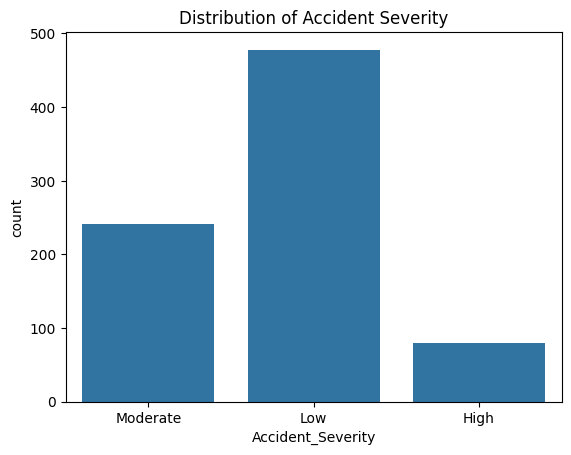

In [ ]:
sns.countplot(x='Accident_Severity', data=df)
plt.title('Distribution of Accident Severity')
plt.show()


This bar plot illustrates the distribution of the class label. It is clearly visible that the 'Low' category heavily dominates the dataset, while other classes are significantly less frequent. This uneven distribution highlights a class imbalance issue that might require attention during the modeling phase to prevent bias.

**Variables Relationship**

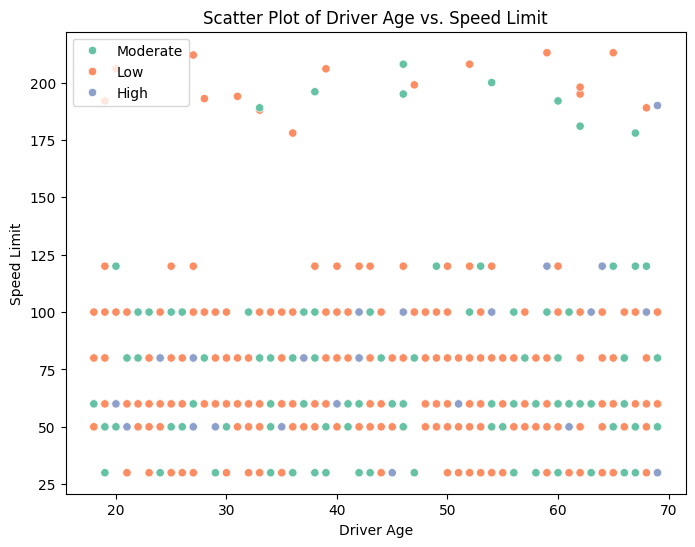

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Driver_Age', y='Speed_Limit', data=df, hue='Accident_Severity', palette='Set2')
plt.title('Scatter Plot of Driver Age vs. Speed Limit')
plt.xlabel('Driver Age')
plt.ylabel('Speed Limit')
plt.legend(loc='upper left')
plt.show()

This scatter plot explores the relationship between driver age and speed limits. The plot reveals the concentration of accidents in specific ranges, along with the presence of some scattered or extreme points. This observation strongly justifies the necessity of applying Noise Removal to clean the dataset from outliers.

**Variable Distributions**

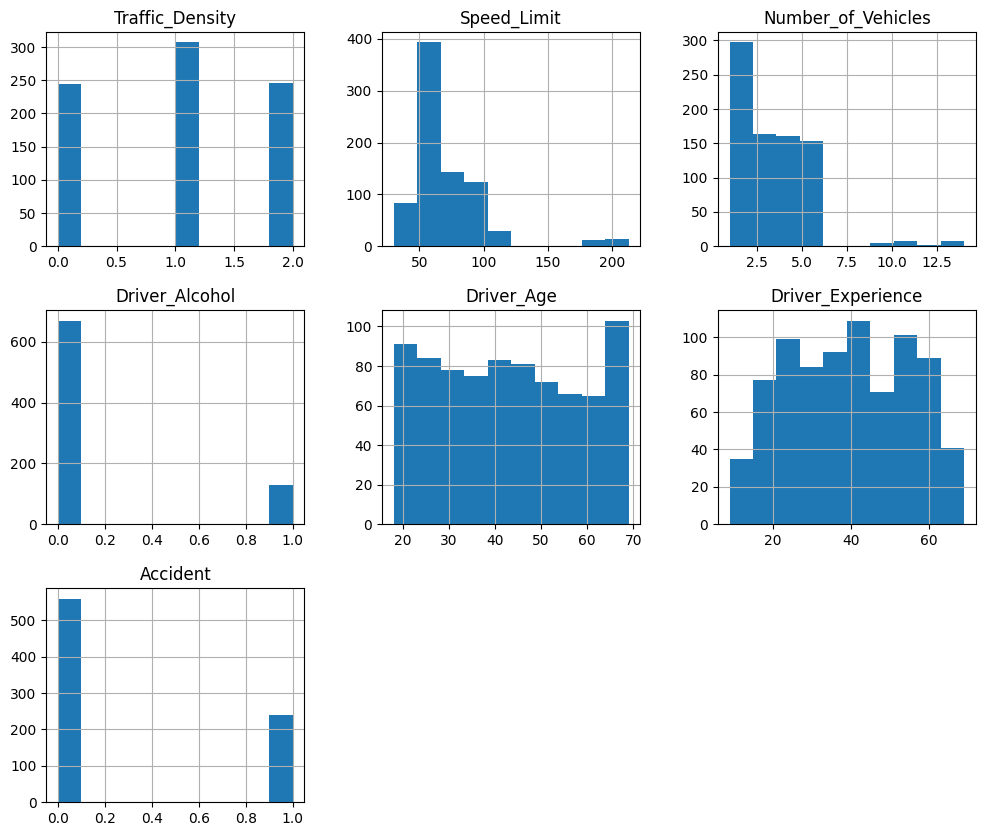

In [ ]:
df.hist(figsize=(12,10))
plt.show()

These histograms display the statistical distributions of the numeric variables. The clear differences in data scales across columns confirm that the raw data requires preprocessing. Consequently, we must apply Normalization to scale the data uniformly before feeding them into the predictive models.

**Missing Values Analysis**

In [ ]:

print("\nMissing Values:")
print (df.isnull().sum())


Missing Values:
Weather                 42
Road_Type               42
Time_of_Day             42
Traffic_Density         42
Speed_Limit             42
Number_of_Vehicles      42
Driver_Alcohol          42
Accident_Severity       42
Road_Condition          42
Vehicle_Type            42
Driver_Age              42
Driver_Experience       42
Road_Light_Condition    42
Accident                42
dtype: int64


In [4]:
column_means = Preprocessed_dataset.mean(numeric_only=True)
Preprocessed_dataset= Preprocessed_dataset.fillna(column_means)
Preprocessed_dataset=Preprocessed_dataset.dropna()
print ("\nMissing Values:")
print (Preprocessed_dataset.isnull(). sum())


Missing Values:
Weather                 0
Road_Type               0
Time_of_Day             0
Traffic_Density         0
Speed_Limit             0
Number_of_Vehicles      0
Driver_Alcohol          0
Accident_Severity       0
Road_Condition          0
Vehicle_Type            0
Driver_Age              0
Driver_Experience       0
Road_Light_Condition    0
Accident                0
dtype: int64


We first checked for missing values in the dataset, then replaced missing numerical values with the column mean and removed rows with missing non-numerical values.

**Statistical Summaries**

In [ ]:
df.describe()

,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Driver_Age,Driver_Experience,Accident
count,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000
mean,0.996650,70.925730,3.272395,0.160363,43.505591,39.179651,0.304405
std,0.759461,30.629957,1.950758,0.357102,14.610937,14.826935,0.449134
min,0.000000,30.000000,1.000000,0.000000,18.000000,9.000000,0.000000
25%,0.000000,50.000000,2.000000,0.000000,32.000000,27.000000,0.000000
50%,1.000000,60.000000,3.000000,0.000000,43.259398,38.981203,0.000000
75%,2.000000,80.000000,4.000000,0.000000,55.000000,52.000000,1.000000
max,2.000000,213.000000,14.000000,1.000000,69.000000,69.000000,1.000000


Statistical summaries provide important information about the dataset, such as the average, Standard Deviation, minimum, maximum, and data range. They help us understand the dataset and its distribution.

# 2-Data Preprocessing

**Applying preprocessing techniques**





**Raw Dataset Snapshot**

In [ ]:
df.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
1,Clear,Rural Road,Night,1.001253,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.000000,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.000000,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.000000,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0
6,Foggy,Highway,Afternoon,0.000000,60.0,4.0,0.0,Low,Dry,Truck,27.0,26.0,Daylight,1.0


**Noise Removal**

In [5]:
speed_column = Preprocessed_dataset['Speed_Limit']
mean_speed = speed_column.mean()
differences_from_mean = abs(speed_column - mean_speed)
max_difference_index = differences_from_mean.idxmax()
Preprocessed_dataset = Preprocessed_dataset.drop(max_difference_index)


Justification (Why): To prevent extreme outliers from skewing statistical measures and negatively impacting the learning process of machine learning algorithms.

How you applied it: Using the mean method, calculating the mean of the column, finding the absolute differences from the mean for each value, identifying the index of the largest difference using idxmax(), and removing that specific row using the drop() function.

On which attributes: Applied to the Speed_Limit attribute.

Preprocessing Results & Improvement: The dataset is now free from the most extreme outlier, which reduces variance and stabilizes the data distribution. This prevents algorithms from building incorrect assumptions based on abnormal values.

**Normalization**

In [6]:
from sklearn.preprocessing import MinMaxScaler
columns_to_normalize = ['Speed_Limit']
data_to_normalize = Preprocessed_dataset[columns_to_normalize]
minmax_scaler = MinMaxScaler()
normalized_data_minmax = minmax_scaler.fit_transform(data_to_normalize)
Preprocessed_dataset[columns_to_normalize] = normalized_data_minmax


Justification (Why): To scale the features to a standard range, ensuring that variables with large numeric values do not unfairly dominate the model's performance and that all features contribute equally.

How you applied it: Used the MinMaxScaler from sklearn.preprocessing to apply Min-Max scaling, which transforms all values of the target attribute into a uniform range between 0 and 1.

On which attributes: Applied to the Speed_Limit attribute.

Preprocessing Results & Improvement: All speed values are now confined within a standard unified range (between 0 and 1). This improves the dataset's efficiency by speeding up algorithm convergence and preventing bias caused by disparities in absolute number sizes.

**Discretization using equal-width binning**

In [7]:
Preprocessed_dataset['Driver_Age'] = pd.cut(
    Preprocessed_dataset['Driver_Age'],
    bins=3,
    labels=['Young', 'Middle-aged', 'Older']
)


Discretization
Attribute: Driver_Age

How: Applied equal-width discretization to Driver_Age by dividing its numerical range (18–69) into three approximately equal-width intervals. The original numerical values in the processed dataset were replaced with the category labels Young (18–34), Middle-aged (35–51), and Older (52–69).

Why: Driver_Age contains many individual numerical values. Discretizing it into three age groups simplifies the attribute and makes age-related patterns in traffic accidents easier to interpret.

Result and Improvement: Driver_Age was transformed from a numerical attribute into a categorical attribute with three age groups. This reduces the number of distinct values and provides a simpler, more interpretable representation of driver age while keeping the original raw dataset unchanged. This meets the project's requirement to explain the technique, attribute, justification, and resulting improvement.

**Preprocessed Dataset Snapshot**

In [ ]:
Preprocessed_dataset.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
1,Clear,Rural Road,Night,1.001253,0.491803,3.0,0.0,Moderate,Wet,Truck,Middle-aged,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.000000,0.163934,4.0,0.0,Low,Icy,Car,Older,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.000000,0.163934,3.0,0.0,Low,Under Construction,Bus,Young,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.000000,0.901639,11.0,0.0,Low,Dry,Car,Older,55.0,Artificial Light,1.0
6,Foggy,Highway,Afternoon,0.000000,0.163934,4.0,0.0,Low,Dry,Truck,Young,26.0,Daylight,1.0


In [8]:
Preprocessed_dataset.to_csv('Preprocessed_dataset.csv', index=False)